# Estimación de recursos en presencia de incertidumbre geológica
### Port a Python de la memoria de título (Ing. Civil de Minas, UdeC, 2019) — Eric Rodríguez

**Versión 2** de este notebook: la simulación de variables categóricas (tipo de roca, alteración,
textura) ya no usa un motor de cadenas de Markov espaciales (equivalente a `spMC`), sino un
**modelo de Machine Learning** (Random Forest). Además, la Sección 3 (caso real) quedó
**parametrizada** para que puedas cargar cualquier base de datos de sondajes propia, sin tocar
el resto del código — solo editas los nombres de columnas en una celda de configuración.

**Estructura:**
1. Imports y motor de simulación categórica basado en ML
2. Caso ficticio (datos 100% sintéticos, igual que en la memoria)
3. Caso real — **configurable**: apunta a tu propio archivo de sondajes
4. Conclusiones y notas de uso


## 0. Imports y configuración

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from sklearn.ensemble import RandomForestClassifier
import gstools as gs

RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)
plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True


## 1. Motor de simulación categórica basado en Machine Learning

Reemplaza el enfoque de cadenas de Markov espaciales (`spMC`) por un **RandomForestClassifier**
que aprende, a partir de los datos condicionantes (sondajes), la relación entre la configuración
de los `k` vecinos más cercanos (distancia + categoría de cada uno) y la categoría en un punto.
Es una idea de *machine learning aplicado a geoestadística*: en vez de asumir una forma analítica
para la transición espacial (como hace un transiograma), se deja que el modelo aprenda el patrón
directamente de los datos.

Dos formas de generar una realización, pensadas para usos distintos:

| Función | Cómo funciona | Cuándo usarla |
|---|---|---|
| `ml_sequential_simulate` | Recorre la grilla en orden aleatorio; en cada nodo predice y sortea la categoría, y la **agrega al set condicionante** de los nodos siguientes (como una simulación secuencial clásica) | Da más continuidad espacial. Más lenta — grillas chicas/medianas |
| `ml_batch_simulate` | Predice y sortea **todos** los nodos de una vez, usando solo los datos duros originales | Mucho más rápida (~100-300x) — grillas grandes o cuando necesitas repetir la simulación muchas veces (p.ej. análisis de sensibilidad) |

El modelo (`train_classifier`) se entrena **una sola vez** por variable categórica; cada
realización adicional solo cambia el camino aleatorio y el sorteo Monte Carlo (igual que en una
simulación secuencial clásica, donde el modelo de variograma es fijo y la aleatoriedad viene del
camino y de los residuos).


In [2]:
"""
Motor de simulación categórica basado en Machine Learning
-----------------------------------------------------------
Reemplaza el enfoque de cadenas de Markov espaciales (spMC / Sección 1
de la versión anterior de este notebook) por un clasificador supervisado
(Random Forest) que aprende, a partir de los datos condicionantes, la
relación entre la configuración de los vecinos más cercanos (distancia +
categoría) y la categoría en un punto.

La simulación se hace de forma SECUENCIAL (igual estructura que la
simulación geoestadística clásica):
  1. Se recorre la grilla objetivo en un orden aleatorio.
  2. En cada nodo, se arma un vector de features con los `k` vecinos
     condicionantes más cercanos (datos originales + nodos ya simulados).
  3. El modelo entrega una probabilidad para cada categoría.
  4. Se sortea (Monte Carlo) la categoría según esa probabilidad y se
     agrega al set condicionante para los siguientes nodos.

Repetir el proceso con distintas semillas produce distintas realizaciones
(simulaciones), igual que en el enfoque anterior.
"""
import numpy as np
from sklearn.ensemble import RandomForestClassifier


def _neighbor_features(coords_all, cats_idx_all, query, k, n_categories):
    """Vector de features de un punto: para sus k vecinos más cercanos,
    concatena [distancia, one-hot de categoría]. Si hay menos de k puntos
    disponibles, rellena con distancia grande y one-hot en cero."""
    d = np.linalg.norm(coords_all - query, axis=1)
    order = np.argsort(d)[:k]
    feats = np.zeros(k * (1 + n_categories))
    for slot, idx in enumerate(order):
        feats[slot * (1 + n_categories)] = d[idx]
        feats[slot * (1 + n_categories) + 1 + cats_idx_all[idx]] = 1.0
    for slot in range(len(order), k):
        feats[slot * (1 + n_categories)] = d.max() * 3 if len(d) else 1e6
    return feats


def build_training_set(coords, cats_idx, k, n_categories):
    """Set de entrenamiento leave-one-out: para cada punto condicionante,
    sus features son la configuración de SUS vecinos más cercanos entre
    el resto de los datos, y su etiqueta es su propia categoría."""
    n = len(coords)
    X = np.zeros((n, k * (1 + n_categories)))
    for i in range(n):
        mask = np.arange(n) != i
        X[i] = _neighbor_features(coords[mask], cats_idx[mask], coords[i], k, n_categories)
    return X, cats_idx


def train_classifier(coords_cond, cats_cond, categories, k=8, n_estimators=200, random_state=None):
    """Entrena el Random Forest UNA vez sobre los datos condicionantes.
    Se reutiliza para las N simulaciones (cada una varía por el orden
    aleatorio del recorrido y por el sorteo Monte Carlo, igual que en
    una simulación secuencial clásica donde el modelo de variograma es
    fijo y la aleatoriedad viene del camino y de los residuos)."""
    cat_index = {c: i for i, c in enumerate(categories)}
    n_cat = len(categories)
    cats_idx_cond = np.array([cat_index[c] for c in cats_cond])
    X_train, y_train = build_training_set(np.asarray(coords_cond), cats_idx_cond, k, n_cat)
    clf = RandomForestClassifier(
        n_estimators=n_estimators, max_depth=None, min_samples_leaf=2,
        random_state=random_state, n_jobs=-1,
    )
    clf.fit(X_train, y_train)
    return clf


def ml_sequential_simulate(coords_cond, cats_cond, coords_target, categories,
                            clf, k=8, random_state=None):
    """Una realización de la simulación secuencial usando un clasificador
    YA ENTRENADO (ver `train_classifier`)."""
    rng = np.random.default_rng(random_state)
    cat_index = {c: i for i, c in enumerate(categories)}
    n_cat = len(categories)
    cats_idx_cond = np.array([cat_index[c] for c in cats_cond])
    trained_classes = clf.classes_

    all_coords = list(np.asarray(coords_cond))
    all_cats_idx = list(cats_idx_cond)
    sim_idx = np.empty(len(coords_target), dtype=int)

    order = rng.permutation(len(coords_target))
    for oi in order:
        u0 = coords_target[oi]
        feats = _neighbor_features(np.asarray(all_coords), np.asarray(all_cats_idx), u0, k, n_cat)
        proba_partial = clf.predict_proba(feats.reshape(1, -1))[0]
        proba = np.zeros(n_cat)
        proba[trained_classes] = proba_partial
        proba = proba / proba.sum()
        draw = rng.choice(n_cat, p=proba)
        sim_idx[oi] = draw
        all_coords.append(u0)
        all_cats_idx.append(draw)

    return np.array(categories)[sim_idx]


def ml_batch_simulate(coords_cond, cats_cond, coords_target, categories, clf, k=8,
                       random_state=None):
    """
    Versión vectorizada (no secuencial) de la simulación: calcula la
    probabilidad de cada categoría para TODOS los nodos objetivo en un
    solo llamado al modelo (usando solo los datos condicionantes duros,
    sin actualizar con nodos ya simulados) y sortea cada uno de forma
    independiente.

    Es mucho más rápida que `ml_sequential_simulate` — útil para grillas
    grandes o para generar muchas realizaciones rápidamente (p.ej. un
    análisis de sensibilidad económica que necesita repetir la
    simulación decenas de veces). A cambio, pierde algo de continuidad
    espacial fina respecto a la versión secuencial, porque no encadena
    la información entre nodos simulados.
    """
    from scipy.spatial.distance import cdist

    rng = np.random.default_rng(random_state)
    cat_index = {c: i for i, c in enumerate(categories)}
    n_cat = len(categories)
    coords_cond = np.asarray(coords_cond)
    coords_target = np.asarray(coords_target)
    cats_idx_cond = np.array([cat_index[c] for c in cats_cond])

    dmat = cdist(coords_target, coords_cond)
    order = np.argsort(dmat, axis=1)[:, :k]

    n_target = len(coords_target)
    X = np.zeros((n_target, k * (1 + n_cat)))
    for slot in range(k):
        idx = order[:, slot]
        X[:, slot * (1 + n_cat)] = dmat[np.arange(n_target), idx]
        X[np.arange(n_target), slot * (1 + n_cat) + 1 + cats_idx_cond[idx]] = 1.0

    proba_partial = clf.predict_proba(X)
    proba = np.zeros((n_target, n_cat))
    proba[:, clf.classes_] = proba_partial
    proba = proba / proba.sum(axis=1, keepdims=True)

    cum = np.cumsum(proba, axis=1)
    u = rng.uniform(size=n_target)[:, None]
    draw = (u < cum).argmax(axis=1)
    return np.array(categories)[draw]


In [3]:
def fit_and_simulate_categoricas(train_df, cols_categoricas, coords_cols, target_coords,
                                  n_sim, k=6, n_estimators=80, mode="batch", seed0=0):
    """
    Entrena un clasificador por cada columna categórica y genera `n_sim`
    realizaciones sobre `target_coords`. Devuelve un dict:
        {columna: [simulación_1, simulación_2, ...]}
    """
    coords_tr = train_df[coords_cols].values
    resultados = {}
    for col in cols_categoricas:
        categorias = sorted(train_df[col].dropna().unique())
        clf = train_classifier(coords_tr, train_df[col].values, categorias,
                                k=k, n_estimators=n_estimators, random_state=seed0)
        sims = []
        for s in range(n_sim):
            if mode == "sequential":
                sim = ml_sequential_simulate(coords_tr, train_df[col].values, target_coords,
                                              categorias, clf, k=k, random_state=seed0 + s)
            else:
                sim = ml_batch_simulate(coords_tr, train_df[col].values, target_coords,
                                         categorias, clf, k=k, random_state=seed0 + s)
            sims.append(sim)
        resultados[col] = sims
    return resultados


## 2. Caso ficticio

Replica la lógica de `caso_simulado.R`: se genera una grilla, se simula un modelo geológico de
3 dominios (MG1/MG2/MG3) vía un campo gaussiano no condicional cortado en cuantiles, y dentro de
cada dominio se co-simulan Cu, Mo, Roca y Alteración con distintos parámetros de variabilidad
(igual que los distintos `vgm(...)` por dominio en el script R). La diferencia frente a la v1 de
este notebook: Roca y Alteración ahora se simulan con el motor de **Machine Learning** de la
Sección 1, no con transiogramas.


In [4]:
# ---- 2.1 Grilla ----
xcoord = np.arange(0, 300, 15)
ycoord = np.arange(0, 300, 15)
zcoord = np.arange(0, 150, 15)
gx, gy, gz = np.meshgrid(xcoord, ycoord, zcoord, indexing="ij")
coords_grid = np.column_stack([gx.ravel(), gy.ravel(), gz.ravel()]).astype(float)
print(f"Puntos de la grilla: {len(coords_grid)}")


Puntos de la grilla: 4000


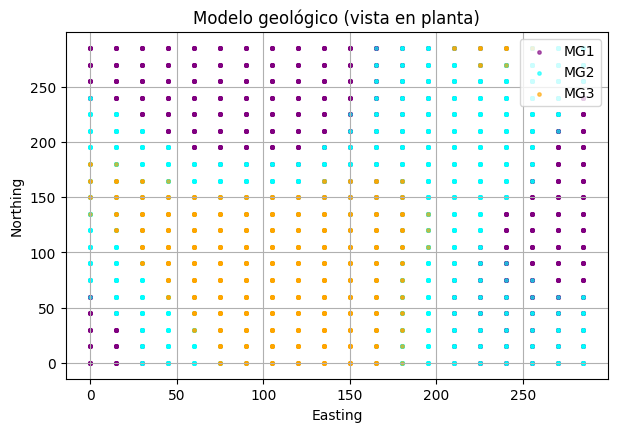

MG1    0.45
MG2    0.35
MG3    0.20
Name: proportion, dtype: float64


In [5]:
# ---- 2.2 Simulación no condicional del modelo geológico (3 dominios) ----
model_dg = gs.Gaussian(dim=3, var=0.5, len_scale=100)
srf_dg = gs.SRF(model_dg, seed=1)
dg_field = srf_dg((coords_grid[:, 0], coords_grid[:, 1], coords_grid[:, 2]))

q = np.quantile(dg_field, [0.45, 0.80])
mg = np.where(dg_field <= q[0], "MG1", np.where(dg_field <= q[1], "MG2", "MG3"))

fig, ax = plt.subplots()
for dom, c in zip(["MG1", "MG2", "MG3"], ["purple", "cyan", "orange"]):
    m = mg == dom
    ax.scatter(coords_grid[m, 0], coords_grid[m, 1], s=6, c=c, label=dom, alpha=0.6)
ax.set_xlabel("Easting"); ax.set_ylabel("Northing"); ax.set_title("Modelo geológico (vista en planta)")
ax.legend()
plt.show()
print(pd.Series(mg).value_counts(normalize=True).round(3))


In [6]:
# ---- 2.3 Co-simulación de Cu, Mo, Roca y Alteración dentro de cada dominio ----
DOMAIN_PARAMS = {
    "MG1": dict(var=1.0, len_scale=90, corr_cu_mo=0.65, seed0=10),
    "MG2": dict(var=0.7, len_scale=70, corr_cu_mo=-0.20, seed0=20),
    "MG3": dict(var=1.0, len_scale=60, corr_cu_mo=0.10, seed0=30),
}

rows = []
for dom, p in DOMAIN_PARAMS.items():
    sub = coords_grid[mg == dom]
    if len(sub) == 0:
        continue
    model = gs.Spherical(dim=3, var=p["var"], len_scale=p["len_scale"], angles=(0.3, 0.1))
    xs, ys, zs = sub[:, 0], sub[:, 1], sub[:, 2]
    common = gs.SRF(model, seed=p["seed0"])((xs, ys, zs))
    cu_noise = gs.SRF(model, seed=p["seed0"] + 1)((xs, ys, zs))
    mo_noise = gs.SRF(model, seed=p["seed0"] + 2)((xs, ys, zs))
    roca_f = gs.SRF(model, seed=p["seed0"] + 3)((xs, ys, zs))
    alt_f = gs.SRF(model, seed=p["seed0"] + 4)((xs, ys, zs))

    r = p["corr_cu_mo"]
    cu = r * common + np.sqrt(max(1 - r**2, 0)) * cu_noise
    mo = r * common + np.sqrt(max(1 - r**2, 0)) * mo_noise

    cu = 10 * (np.exp(cu) - np.exp(cu).min()) / (np.exp(cu).max() - np.exp(cu).min())
    mo = (np.exp(mo) - np.exp(mo).min()) / (np.exp(mo).max() - np.exp(mo).min()) / 10 * 2

    roca_cat = pd.cut(roca_f, bins=4, labels=[f"Roca{i}" for i in range(1, 5)]).astype(str)
    alt_cat = pd.cut(alt_f, bins=3, labels=[f"Alteracion{i}" for i in range(1, 4)]).astype(str)

    rows.append(pd.DataFrame({
        "Easting": xs, "Northing": ys, "Elevation": zs, "MG": dom,
        "Cu": cu, "Mo": mo, "Roca": roca_cat, "Alteracion": alt_cat,
    }))

base_completa = pd.concat(rows, ignore_index=True)
base_completa["Observacion"] = np.arange(len(base_completa))
base_completa.head()


,Easting,Northing,Elevation,MG,Cu,Mo,Roca,Alteracion,Observacion
0,0.0,0.0,0.0,MG1,0.397285,0.003841,Roca2,Alteracion2,0
1,0.0,0.0,15.0,MG1,0.207859,0.003140,Roca2,Alteracion2,1
2,0.0,0.0,30.0,MG1,1.393927,0.020423,Roca2,Alteracion2,2
3,0.0,0.0,45.0,MG1,0.371878,0.024948,Roca2,Alteracion2,3
4,0.0,0.0,60.0,MG1,0.133891,0.012877,Roca2,Alteracion1,4


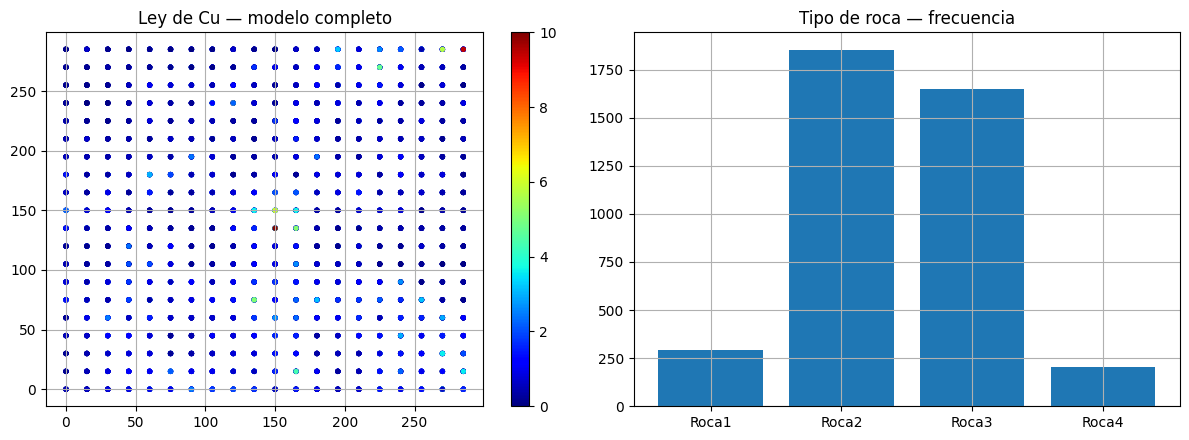

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sca = axes[0].scatter(base_completa.Easting, base_completa.Northing, c=base_completa.Cu, cmap="jet", s=8)
axes[0].set_title("Ley de Cu — modelo completo"); plt.colorbar(sca, ax=axes[0])
axes[1].bar(*np.unique(base_completa.Roca, return_counts=True))
axes[1].set_title("Tipo de roca — frecuencia")
plt.tight_layout(); plt.show()


Entrenamiento (sondajes): 167  |  Validación: 3861


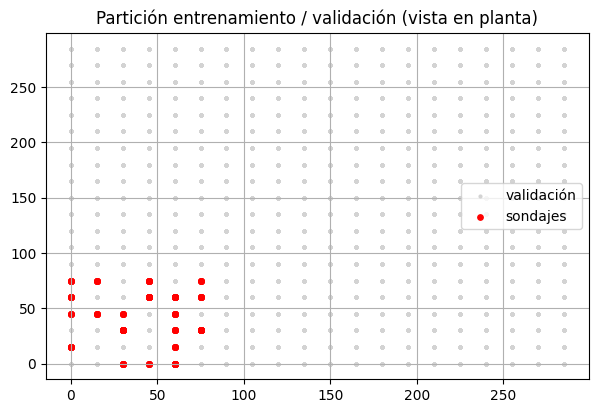

In [8]:
# ---- 2.4 Sondajes sintéticos y partición entrenamiento / validación ----
N_SONDAJES = 25
ex = rng.choice(np.arange(0, 90, 15), N_SONDAJES)
ny = rng.choice(np.arange(0, 90, 15), N_SONDAJES)

frames = []
for i in range(N_SONDAJES):
    zmax = rng.uniform(60, 130)
    m = (np.isclose(base_completa.Easting, ex[i]) &
         np.isclose(base_completa.Northing, ny[i]) &
         (base_completa.Elevation <= zmax))
    d = base_completa[m].copy()
    d["Sondaje"] = i
    frames.append(d)

entrenamiento = pd.concat(frames, ignore_index=True) if frames else base_completa.iloc[0:0].copy()
val_idx = base_completa.index.difference(pd.concat(frames).index if frames else pd.Index([]))
validacion = base_completa.loc[val_idx].reset_index(drop=True)

print(f"Entrenamiento (sondajes): {len(entrenamiento)}  |  Validación: {len(validacion)}")

fig, ax = plt.subplots()
ax.scatter(validacion.Easting, validacion.Northing, s=4, c="lightgray", label="validación")
ax.scatter(entrenamiento.Easting, entrenamiento.Northing, s=15, c="red", label="sondajes")
ax.set_title("Partición entrenamiento / validación (vista en planta)"); ax.legend()
plt.show()


In [9]:
# ---- 2.5 Simulación de Roca y Alteración con Machine Learning ----
N_SIM = 20  # con el motor ML (modo batch) esto corre en menos de un segundo
target_coords = validacion[["Easting", "Northing", "Elevation"]].values

sims = fit_and_simulate_categoricas(
    entrenamiento, ["Roca", "Alteracion"], ["Easting", "Northing", "Elevation"],
    target_coords, n_sim=N_SIM, k=6, n_estimators=100, mode="batch", seed0=0,
)
sim_roca_list = sims["Roca"]
sim_alt_list = sims["Alteracion"]

print(f"{N_SIM} simulaciones de Roca y Alteración generadas sobre {len(target_coords)} nodos de validación.")
print("Frecuencias simulación 1 (Roca):", pd.Series(sim_roca_list[0]).value_counts(normalize=True).round(3).to_dict())
print("Frecuencias validación   (Roca):", validacion["Roca"].value_counts(normalize=True).round(3).to_dict())


20 simulaciones de Roca y Alteración generadas sobre 3861 nodos de validación.
Frecuencias simulación 1 (Roca): {'Roca3': 0.531, 'Roca2': 0.336, 'Roca1': 0.071, 'Roca4': 0.062}
Frecuencias validación   (Roca): {'Roca2': 0.461, 'Roca3': 0.415, 'Roca1': 0.073, 'Roca4': 0.051}


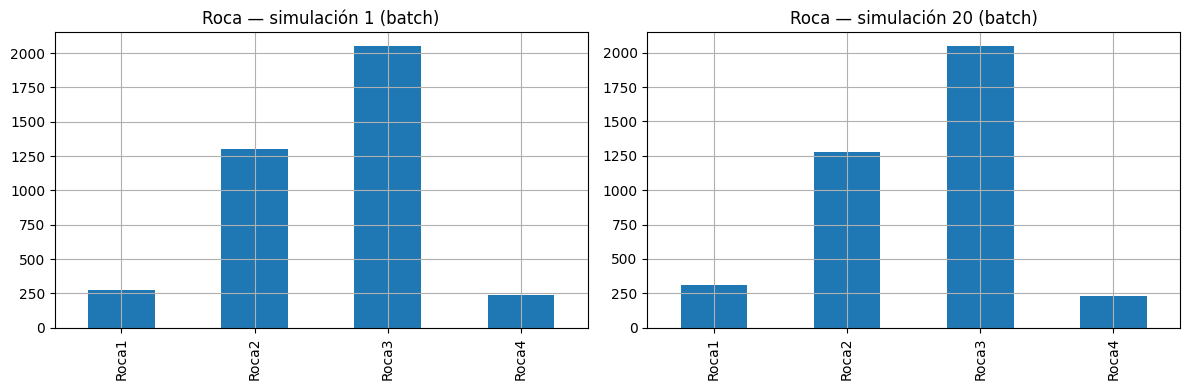

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pd.Series(sim_roca_list[0]).value_counts().sort_index().plot(kind="bar", ax=axes[0], title="Roca — simulación 1 (batch)")
pd.Series(sim_roca_list[-1]).value_counts().sort_index().plot(kind="bar", ax=axes[1], title=f"Roca — simulación {N_SIM} (batch)")
plt.tight_layout(); plt.show()


**Nota sobre continuidad espacial:** el modo `batch` es rápido pero, al no encadenar
información entre nodos simulados, puede verse algo más “ruidoso” (menos parches compactos) que
una simulación secuencial clásica. Si te importa más la continuidad espacial que la velocidad,
usa `mode="sequential"` en `fit_and_simulate_categoricas` — la celda de abajo lo muestra sobre un
subconjunto pequeño, solo para comparar visualmente.

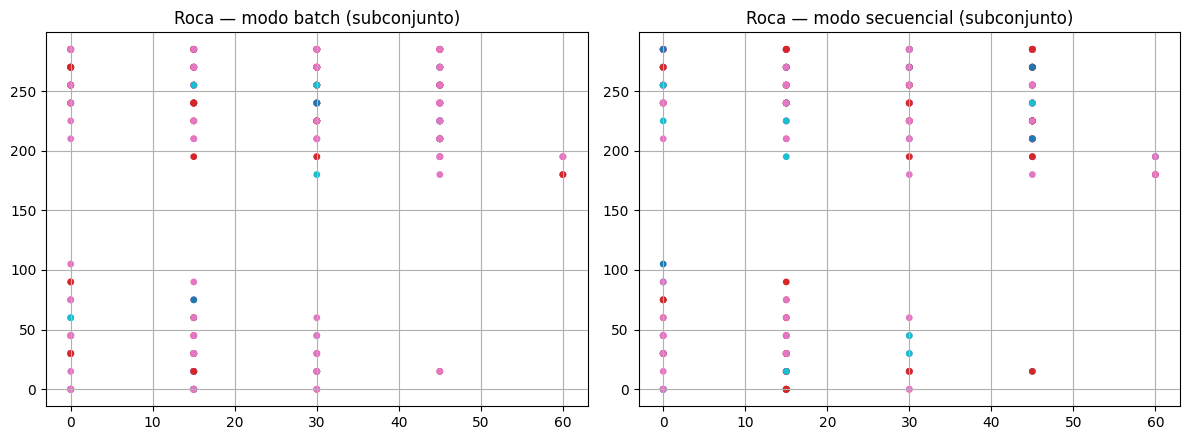

In [11]:
# Comparación rápida: una realización secuencial sobre un subconjunto (más lenta, más continua)
target_subset = target_coords[:300]
sims_seq = fit_and_simulate_categoricas(
    entrenamiento, ["Roca"], ["Easting", "Northing", "Elevation"],
    target_subset, n_sim=1, k=6, n_estimators=80, mode="sequential", seed0=0,
)
sim_roca_seq = sims_seq["Roca"][0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(target_subset[:, 0], target_subset[:, 1], c=pd.Categorical(sim_roca_list[0][:300]).codes, cmap="tab10", s=15)
axes[0].set_title("Roca — modo batch (subconjunto)")
axes[1].scatter(target_subset[:, 0], target_subset[:, 1], c=pd.Categorical(sim_roca_seq).codes, cmap="tab10", s=15)
axes[1].set_title("Roca — modo secuencial (subconjunto)")
plt.tight_layout(); plt.show()


Spherical(dim=3, var=0.619, len_scale=36.7)


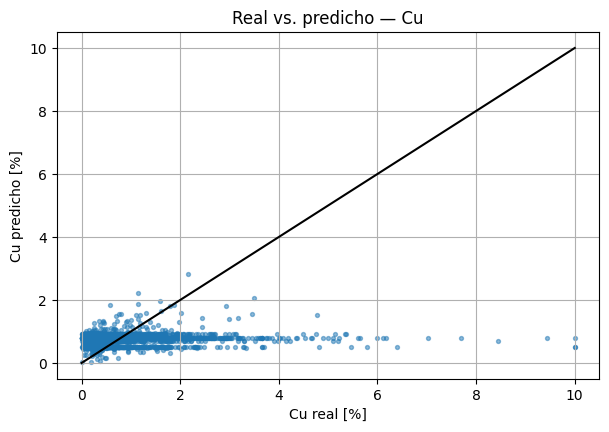

In [12]:
# ---- 2.6 Kriging (regresión + residual kriging) de Cu y Mo usando Roca+Alteración como deriva ----
def regression_kriging(train_df, target_df, roca_col, alt_col, value_col,
                        model_kwargs=None, bin_edges=None):
    """
    Equivalente aproximado al `krige(Cu ~ Roca + Alteracion, ..., block=...)`
    de gstat: regresión lineal sobre dummies de Roca/Alteración (la 'deriva')
    + kriging ordinario de los residuos (GSTools).
    """
    X_train = pd.get_dummies(train_df[[roca_col, alt_col]], drop_first=True).astype(float)
    X_train.insert(0, "intercept", 1.0)
    beta, *_ = np.linalg.lstsq(X_train.values, train_df[value_col].values, rcond=None)
    resid = train_df[value_col].values - X_train.values @ beta

    coords = (train_df.Easting.values, train_df.Northing.values, train_df.Elevation.values)
    if bin_edges is None:
        bin_edges = np.linspace(0, 150, 12)
    bin_c, gamma = gs.vario_estimate(coords, resid, bin_edges, latlon=False)
    model = gs.Spherical(dim=3, **(model_kwargs or {}))
    model.fit_variogram(bin_c, gamma, nugget=True)

    krig = gs.krige.Ordinary(model, coords, resid)
    tcoords = (target_df.Easting.values, target_df.Northing.values, target_df.Elevation.values)
    resid_pred, resid_var = krig(tcoords)

    X_target = pd.get_dummies(target_df[[roca_col, alt_col]], drop_first=True).astype(float)
    for c in X_train.columns:
        if c not in X_target.columns:
            X_target[c] = 0.0
    X_target = X_target[X_train.columns.drop("intercept")]
    X_target.insert(0, "intercept", 1.0)

    trend_pred = X_target.values @ beta
    pred = trend_pred + resid_pred
    return pred, resid_var, model


validacion_dom = validacion.copy()
validacion_dom["Roca_real"] = validacion_dom["Roca"]           # se guarda el valor verdadero solo para referencia/gráficos
validacion_dom["Alteracion_real"] = validacion_dom["Alteracion"]
validacion_dom["Roca"] = sim_roca_list[0]                       # se sobrescribe con la simulación (dominio de estimación)
validacion_dom["Alteracion"] = sim_alt_list[0]

cu_pred, cu_var, model_cu = regression_kriging(entrenamiento, validacion_dom, "Roca", "Alteracion", "Cu")
mo_pred, mo_var, model_mo = regression_kriging(entrenamiento, validacion_dom, "Roca", "Alteracion", "Mo")

validacion_dom["Cu_pred"] = np.clip(cu_pred, 0, None)
validacion_dom["Cu_var"] = cu_var
validacion_dom["Mo_pred"] = np.clip(mo_pred, 0, None)
validacion_dom["Mo_var"] = mo_var

print(model_cu)
fig, ax = plt.subplots()
ax.scatter(validacion_dom.Cu, validacion_dom.Cu_pred, s=8, alpha=0.5)
lims = [0, max(validacion_dom.Cu.max(), validacion_dom.Cu_pred.max())]
ax.plot(lims, lims, "k-")
ax.set_xlabel("Cu real [%]"); ax.set_ylabel("Cu predicho [%]"); ax.set_title("Real vs. predicho — Cu")
plt.show()


Categoria
Medido    1.0
Name: proportion, dtype: float64


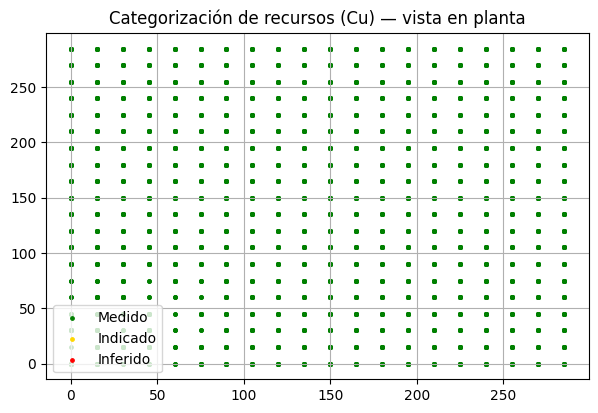

In [13]:
# ---- 2.7 Categorización de recursos según varianza de kriging (Medido / Indicado / Inferido) ----
def categorizar_recursos(var_kriging, q_medido=0.33, q_indicado=0.66):
    q1, q2 = np.quantile(var_kriging, [q_medido, q_indicado])
    cat = np.where(var_kriging <= q1, "Medido", np.where(var_kriging <= q2, "Indicado", "Inferido"))
    return cat

validacion_dom["Categoria"] = categorizar_recursos(validacion_dom["Cu_var"].values)
print(validacion_dom["Categoria"].value_counts(normalize=True).round(3))

fig, ax = plt.subplots()
colors = {"Medido": "green", "Indicado": "gold", "Inferido": "red"}
for cat, c in colors.items():
    m = validacion_dom.Categoria == cat
    ax.scatter(validacion_dom.Easting[m], validacion_dom.Northing[m], s=6, c=c, label=cat)
ax.legend(); ax.set_title("Categorización de recursos (Cu) — vista en planta")
plt.show()


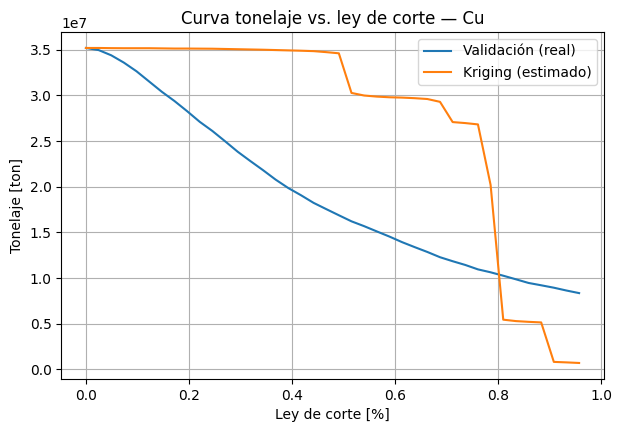

In [14]:
# ---- 2.8 Curva tonelaje - ley ----
BLOCK_VOLUME = 15**3  # m3, tamaño de celda de la grilla usada
DENSITY = 2.7  # ton/m3, densidad típica de roca mineralizada (ajustar según el depósito real)

def curva_tonelaje_ley(df, grade_col, cutoffs):
    ton, ley_media = [], []
    for cutoff in cutoffs:
        sel = df[grade_col] >= cutoff
        t = sel.sum() * BLOCK_VOLUME * DENSITY
        l = df.loc[sel, grade_col].mean() if sel.any() else 0.0
        ton.append(t); ley_media.append(l)
    return np.array(ton), np.array(ley_media)

cutoffs = np.linspace(0, validacion_dom.Cu_pred.quantile(0.98), 40)
ton_val, ley_val = curva_tonelaje_ley(validacion, "Cu", cutoffs)
ton_sim, ley_sim = curva_tonelaje_ley(validacion_dom, "Cu_pred", cutoffs)

fig, ax1 = plt.subplots()
ax1.plot(cutoffs, ton_val, label="Validación (real)")
ax1.plot(cutoffs, ton_sim, label="Kriging (estimado)")
ax1.set_xlabel("Ley de corte [%]"); ax1.set_ylabel("Tonelaje [ton]")
ax1.legend(); ax1.set_title("Curva tonelaje vs. ley de corte — Cu")
plt.show()


In [15]:
# ---- 2.9 Análisis económico ----
PRECIO_CU_USD_TON = 8500  # ajustar al escenario de precio que se quiera evaluar
LEY_CORTE = 0.2

def ingresos(df, grade_col, cutoff, precio_usd_ton):
    sel = df[grade_col] >= cutoff
    ton = sel.sum() * BLOCK_VOLUME * DENSITY
    cu_fino_ton = ton * df.loc[sel, grade_col].mean() / 100 if sel.any() else 0.0
    return ton, cu_fino_ton, cu_fino_ton * precio_usd_ton

ton_v, fino_v, ing_v = ingresos(validacion, "Cu", LEY_CORTE, PRECIO_CU_USD_TON)
ton_s, fino_s, ing_s = ingresos(validacion_dom, "Cu_pred", LEY_CORTE, PRECIO_CU_USD_TON)

resumen = pd.DataFrame({
    "Tonelaje [ton]": [ton_v, ton_s],
    "Cu fino [ton]": [fino_v, fino_s],
    "Ingresos [USD]": [ing_v, ing_s],
}, index=["Validación", "Kriging (dominio simulado)"])
resumen


,Tonelaje [ton],Cu fino [ton],Ingresos [USD]
Validación,28075612.5,247818.935895,2.106461e+09
Kriging (dominio simulado),35110462.5,268139.217878,2.279183e+09


> **Nota:** al igual que en la memoria original, es esperable que el kriging **sobreestime**
> levemente los ingresos respecto a la validación real, por el efecto de suavizamiento típico
> del kriging (regresión hacia la media). Compara `resumen` arriba con el hallazgo de la Tabla 3
> de la presentación original.

## 3. Caso real — configurable para cualquier base de datos

Esta sección quedó parametrizada: **edita solo la celda de configuración** de abajo (ruta del
archivo y nombres de columnas) para usarla con tu propia base de sondajes — no hace falta tocar
el resto del código. Si `RUTA_DATOS_REAL` no existe, se genera automáticamente una base
sintética con el mismo esquema de columnas que definas, para que el notebook completo siga
corriendo de punta a punta como plantilla de referencia.


In [16]:
# =========================== CONFIGURACIÓN — EDITA ESTO ===========================
RUTA_DATOS_REAL = "datos_real.csv"     # ruta a tu archivo (csv/txt), o deja así para usar datos sintéticos

COL_X, COL_Y, COL_Z = "Easting", "Northing", "Elevation"   # nombres de columnas de coordenadas
COLS_CATEGORICAS = ["TIPO_ROC", "TEXTURA"]                  # variable(s) categórica(s) a simular
COL_LEY = "FE"                                              # variable continua a estimar por kriging

# solo se usa si no existe RUTA_DATOS_REAL, para generar datos sintéticos de reemplazo con el
# mismo esquema de columnas de arriba (puedes ignorar esto si ya tienes tu archivo real)
CATEGORIAS_SINTETICAS = {
    "TIPO_ROC": (["AND", "BRH", "DIO", "GRA", "HIE", "MET", "TOB"], [0.18, 0.40, 0.03, 0.01, 0.33, 0.04, 0.01]),
    "TEXTURA": (["AFA", "BRE", "DIA", "DIQ", "MAC", "POR"], [0.10, 0.75, 0.02, 0.01, 0.02, 0.10]),
}
# ====================================================================================


In [17]:
# ---- 3.1 Carga de datos ----
import os

if os.path.exists(RUTA_DATOS_REAL):
    datos_real = pd.read_csv(RUTA_DATOS_REAL)
    print(f"Datos reales cargados desde '{RUTA_DATOS_REAL}': {len(datos_real)} muestras")
    faltantes = [c for c in [COL_X, COL_Y, COL_Z, COL_LEY] + COLS_CATEGORICAS if c not in datos_real.columns]
    if faltantes:
        raise ValueError(f"Columnas no encontradas en el archivo: {faltantes}. "
                          f"Revisa la celda de configuración (COL_X/COL_Y/COL_Z/COLS_CATEGORICAS/COL_LEY).")
else:
    print(f"No se encontró '{RUTA_DATOS_REAL}' — generando datos sintéticos de reemplazo con el "
          f"esquema de columnas configurado arriba.")
    n = 400
    coords_r = np.column_stack([
        rng.uniform(297000, 298000, n),
        rng.uniform(6765200, 6767300, n),
        rng.uniform(850, 1350, n),
    ])
    datos_real = pd.DataFrame({COL_X: coords_r[:, 0], COL_Y: coords_r[:, 1], COL_Z: coords_r[:, 2]})
    for col in COLS_CATEGORICAS:
        if col in CATEGORIAS_SINTETICAS:
            labels, probs = CATEGORIAS_SINTETICAS[col]
        else:
            labels, probs = [f"{col}_{i}" for i in range(1, 5)], None
        datos_real[col] = rng.choice(labels, n, p=probs)
    base_fe = np.where(datos_real[COLS_CATEGORICAS[0]] == datos_real[COLS_CATEGORICAS[0]].mode()[0], 40, 25)
    datos_real[COL_LEY] = np.clip(base_fe + rng.normal(0, 8, n), 5, 70)

datos_real.head()


No se encontró 'datos_real.csv' — generando datos sintéticos de reemplazo con el esquema de columnas configurado arriba.


,Easting,Northing,Elevation,TIPO_ROC,TEXTURA,FE
0,297199.908202,6.765289e+06,939.220881,AND,BRE,33.981426
1,297007.362270,6.767057e+06,949.770996,AND,BRE,24.246443
2,297786.924378,6.766690e+06,1279.491430,AND,BRE,16.112551
3,297664.850857,6.765564e+06,1306.291372,GRA,BRE,34.510273
4,297705.165379,6.765393e+06,956.073704,AND,POR,30.005405


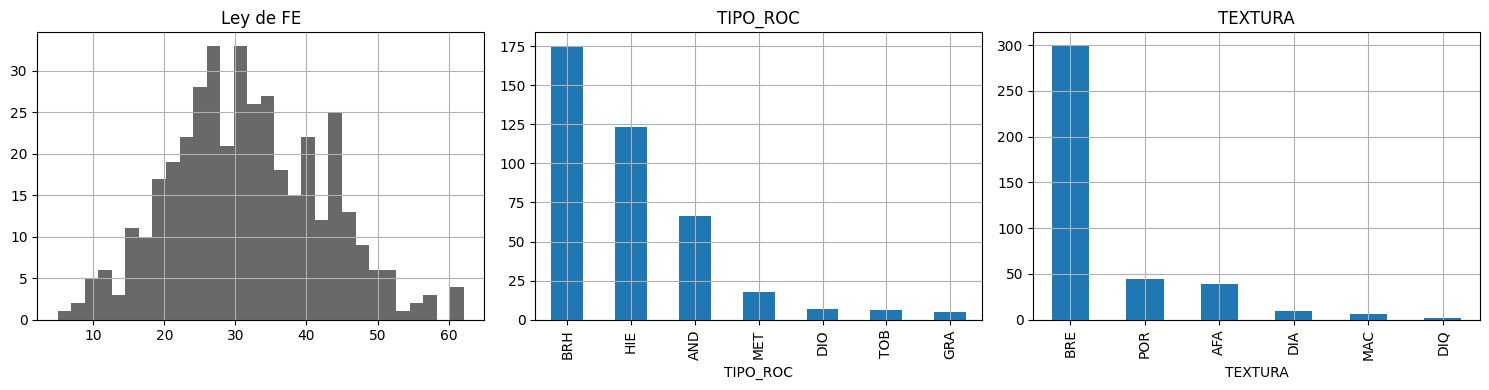

,Easting,Northing,Elevation,FE
count,400.000000,4.000000e+02,400.000000,400.000000
mean,297493.590934,6.766234e+06,1101.183598,31.752478
std,292.535265,6.116529e+02,145.159866,10.713837
min,297005.429834,6.765203e+06,850.259372,5.000000
25%,297231.980953,6.765711e+06,972.324313,24.321190
50%,297502.785506,6.766241e+06,1090.880525,31.294386
75%,297762.879958,6.766751e+06,1229.218241,39.728477
max,297999.104730,6.767297e+06,1349.710955,62.139487


In [18]:
# ---- 3.2 Análisis descriptivo ----
n_cat_cols = len(COLS_CATEGORICAS)
fig, axes = plt.subplots(1, 1 + n_cat_cols, figsize=(5 * (1 + n_cat_cols), 4))
axes = np.atleast_1d(axes)
axes[0].hist(datos_real[COL_LEY], bins=30, color="dimgray")
axes[0].set_title(f"Ley de {COL_LEY}")
for i, col in enumerate(COLS_CATEGORICAS, start=1):
    datos_real[col].value_counts().plot(kind="bar", ax=axes[i], title=col)
plt.tight_layout(); plt.show()

datos_real.select_dtypes("number").describe()


In [19]:
# ---- 3.3 Simulación de las variables categóricas con Machine Learning ----
coords_real = datos_real[[COL_X, COL_Y, COL_Z]].values

# grilla de bloques a estimar (equivalente al "modelo de bloques" del script R; se usa
# una submuestra para que corra rápido — sube n_blocks para un modelo más fino)
n_blocks = 800
block_coords = np.column_stack([
    rng.uniform(coords_real[:, 0].min(), coords_real[:, 0].max(), n_blocks),
    rng.uniform(coords_real[:, 1].min(), coords_real[:, 1].max(), n_blocks),
    rng.uniform(coords_real[:, 2].min(), coords_real[:, 2].max(), n_blocks),
])

N_SIM_REAL = 20  # modo batch -> corre en menos de un segundo incluso con varias variables
sims_real = fit_and_simulate_categoricas(
    datos_real, COLS_CATEGORICAS, [COL_X, COL_Y, COL_Z], block_coords,
    n_sim=N_SIM_REAL, k=6, n_estimators=100, mode="batch", seed0=0,
)

print(f"{N_SIM_REAL} simulaciones generadas sobre {n_blocks} bloques para: {COLS_CATEGORICAS}")


20 simulaciones generadas sobre 800 bloques para: ['TIPO_ROC', 'TEXTURA']


Spherical(dim=3, var=19.1, len_scale=2.48e+02, nugget=43.6)


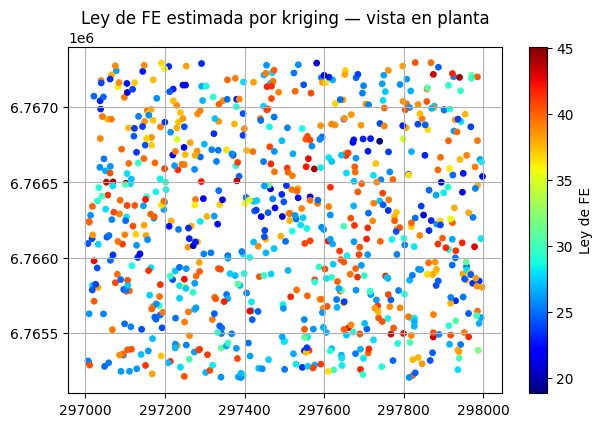

In [20]:
# ---- 3.4 Kriging de la variable de ley usando las categóricas simuladas como deriva ----
bloques = pd.DataFrame({COL_X: block_coords[:, 0], COL_Y: block_coords[:, 1], COL_Z: block_coords[:, 2]})
for col in COLS_CATEGORICAS:
    bloques[col] = sims_real[col][0]

# regression_kriging generaliza a 2 covariables categóricas (usa las 2 primeras de COLS_CATEGORICAS;
# si tu caso tiene solo una, duplícala en la llamada)
cat_a = COLS_CATEGORICAS[0]
cat_b = COLS_CATEGORICAS[1] if len(COLS_CATEGORICAS) > 1 else COLS_CATEGORICAS[0]

ley_pred, ley_var, model_ley = regression_kriging(
    datos_real.rename(columns={COL_X: "Easting", COL_Y: "Northing", COL_Z: "Elevation"}),
    bloques.rename(columns={COL_X: "Easting", COL_Y: "Northing", COL_Z: "Elevation"}),
    cat_a, cat_b, COL_LEY,
    model_kwargs={}, bin_edges=np.linspace(0, 600, 15),
)
bloques[f"{COL_LEY}_pred"] = np.clip(ley_pred, 0, None)
bloques[f"{COL_LEY}_var"] = ley_var

print(model_ley)
fig, ax = plt.subplots()
sca = ax.scatter(bloques[COL_X], bloques[COL_Y], c=bloques[f"{COL_LEY}_pred"], cmap="jet", s=15)
plt.colorbar(sca, ax=ax, label=f"Ley de {COL_LEY}")
ax.set_title(f"Ley de {COL_LEY} estimada por kriging — vista en planta")
plt.show()


Categoria
Inferido    0.34
Medido      0.33
Indicado    0.33
Name: proportion, dtype: float64


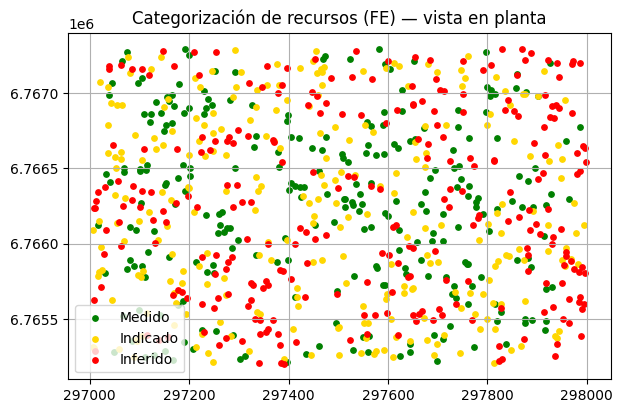

In [21]:
# ---- 3.5 Categorización de recursos ----
bloques["Categoria"] = categorizar_recursos(bloques[f"{COL_LEY}_var"].values)
print(bloques["Categoria"].value_counts(normalize=True).round(3))

fig, ax = plt.subplots()
for cat, c in colors.items():
    m = bloques.Categoria == cat
    ax.scatter(bloques[COL_X][m], bloques[COL_Y][m], s=15, c=c, label=cat)
ax.legend(); ax.set_title(f"Categorización de recursos ({COL_LEY}) — vista en planta")
plt.show()


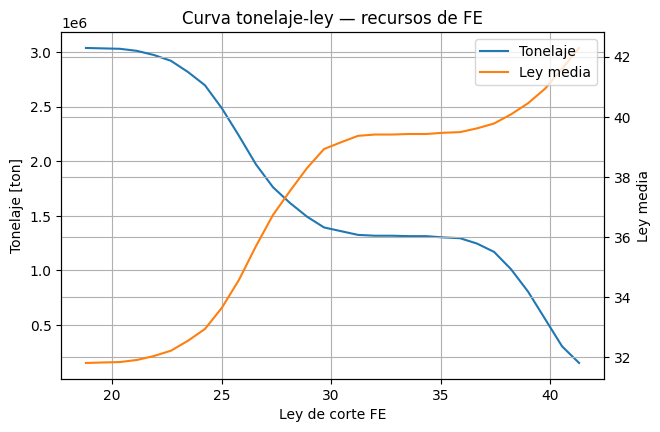

Tonelaje total de recursos: 3,040,000 ton
Tonelaje de reservas (categoría Medido): 1,003,200 ton


In [22]:
# ---- 3.6 Inventario de recursos y curva tonelaje-ley ----
BLOCK_VOLUME_REAL = 1000  # m3, ajustar al tamaño de bloque real de tu modelo
DENSITY_REAL = 3.8        # ton/m3, ajustar a la densidad típica de tu depósito

pred_col = f"{COL_LEY}_pred"
cutoffs_ley = np.linspace(bloques[pred_col].min(), bloques[pred_col].quantile(0.95), 30)
ton_recursos, ley_recursos = [], []
for c in cutoffs_ley:
    sel = bloques[pred_col] >= c
    ton_recursos.append(sel.sum() * BLOCK_VOLUME_REAL * DENSITY_REAL)
    ley_recursos.append(bloques.loc[sel, pred_col].mean() if sel.any() else 0.0)

fig, ax1 = plt.subplots()
ax1.plot(cutoffs_ley, ton_recursos, color="tab:blue", label="Tonelaje")
ax1.set_xlabel(f"Ley de corte {COL_LEY}"); ax1.set_ylabel("Tonelaje [ton]")
ax2 = ax1.twinx()
ax2.plot(cutoffs_ley, ley_recursos, color="tab:orange", label="Ley media")
ax2.set_ylabel("Ley media")
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.88))
ax1.set_title(f"Curva tonelaje-ley — recursos de {COL_LEY}")
plt.show()

reservas_mask = bloques.Categoria == "Medido"
tonelaje_reservas = reservas_mask.sum() * BLOCK_VOLUME_REAL * DENSITY_REAL
tonelaje_recursos_total = len(bloques) * BLOCK_VOLUME_REAL * DENSITY_REAL
print(f"Tonelaje total de recursos: {tonelaje_recursos_total:,.0f} ton")
print(f"Tonelaje de reservas (categoría Medido): {tonelaje_reservas:,.0f} ton")


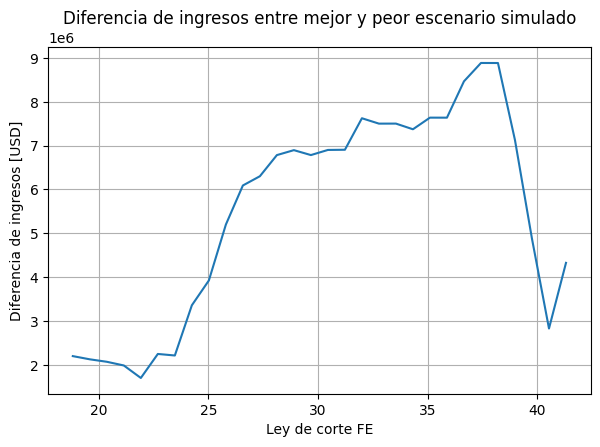

Mayor diferencia: 8,885,827 USD, en ley de corte 37.4


In [23]:
# ---- 3.7 Sensibilidad económica a la ley de corte ----
PRECIO_USD_TON = 100  # ajustar al precio del commodity que estés evaluando

def ingresos_generico(df, pred_col, cutoff, precio):
    sel = df[pred_col] >= cutoff
    ton = sel.sum() * BLOCK_VOLUME_REAL * DENSITY_REAL
    fino = ton * df.loc[sel, pred_col].mean() / 100 if sel.any() else 0.0
    return fino * precio

# gracias al modo "batch", regenerar N_SIM_REAL escenarios completos es rápido
ingresos_por_sim = []
for i in range(N_SIM_REAL):
    b_i = bloques.copy()
    for col in COLS_CATEGORICAS:
        b_i[col] = sims_real[col][i]
    ley_pred_i, _, _ = regression_kriging(
        datos_real.rename(columns={COL_X: "Easting", COL_Y: "Northing", COL_Z: "Elevation"}),
        b_i.rename(columns={COL_X: "Easting", COL_Y: "Northing", COL_Z: "Elevation"}),
        cat_a, cat_b, COL_LEY, bin_edges=np.linspace(0, 600, 15),
    )
    b_i[pred_col] = np.clip(ley_pred_i, 0, None)
    ingresos_por_sim.append([ingresos_generico(b_i, pred_col, c, PRECIO_USD_TON) for c in cutoffs_ley])

ingresos_por_sim = np.array(ingresos_por_sim)
diferencia = ingresos_por_sim.max(axis=0) - ingresos_por_sim.min(axis=0)

fig, ax = plt.subplots()
ax.plot(cutoffs_ley, diferencia)
ax.set_xlabel(f"Ley de corte {COL_LEY}"); ax.set_ylabel("Diferencia de ingresos [USD]")
ax.set_title("Diferencia de ingresos entre mejor y peor escenario simulado")
plt.show()

print(f"Mayor diferencia: {diferencia.max():,.0f} USD, en ley de corte {cutoffs_ley[np.argmax(diferencia)]:.1f}")


## 4. Conclusiones y notas de uso

- El motor de simulación categórica ahora usa **Random Forest** en vez de cadenas de Markov
  espaciales. Usa `mode="batch"` para grillas grandes o análisis repetitivos (rápido), y
  `mode="sequential"` cuando te interese más la continuidad espacial en una realización puntual
  (más lento).
- Puedes ajustar `k` (número de vecinos), `n_estimators` (árboles del bosque) en
  `train_classifier` / `fit_and_simulate_categoricas` para explorar el efecto sobre la
  variabilidad simulada — más vecinos y más árboles suelen dar simulaciones más "suaves" y
  menos ruidosas.
- **Caso real**: para usar tu propia base de datos, solo edita la celda de configuración de la
  Sección 3 (`RUTA_DATOS_REAL`, `COL_X/COL_Y/COL_Z`, `COLS_CATEGORICAS`, `COL_LEY`) — el resto
  del pipeline (simulación, kriging, categorización, inventario, análisis económico) se adapta
  automáticamente a los nombres de columnas que definas.
- El **kriging** sigue resuelto como *regression kriging* (regresión sobre las variables
  categóricas simuladas + kriging ordinario de residuos con GSTools).
- Ajusta densidad (`DENSITY`, `DENSITY_REAL`) y precios (`PRECIO_CU_USD_TON`, `PRECIO_USD_TON`)
  a los valores que quieras evaluar en cada caso.
